In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.tsa import stattools as ts
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import datetime


数据已导出至 processed_returns_data.csv，共 1235355 行


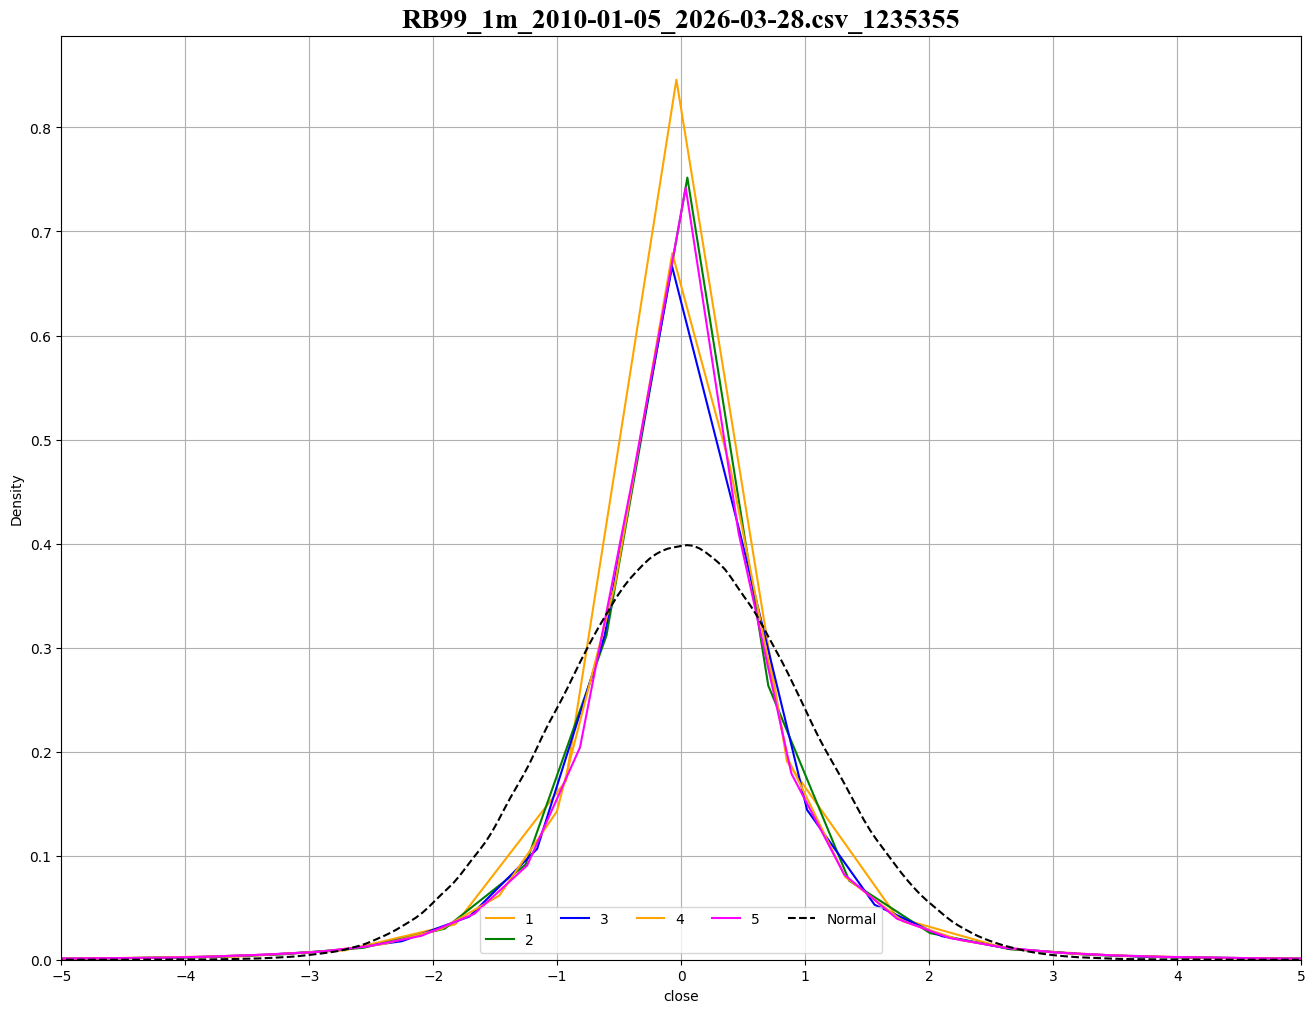

In [13]:
# 这段代码的功能是定义一个文件名，该文件名为 'RB99_1m_2015-01-05_2025-10-10.csv'，用于存储原始数据。
# 然后使用 pandas 库的 read_csv 函数读取该文件中的数据，并将读取的数据存储在变量 bars 中。
# 最后，将数据框 bars 的索引设置为 'datetime' 列，并且直接在原数据框上进行修改。
file_name ='RB99_1m_2010-01-05_2026-03-28.csv'       ###############  原始数据文件 ############### 
bars = pd.read_csv(file_name)
bars.set_index("datetime", inplace=True)

returns_1 = np.log(bars['close']).diff()   ###############  一阶差分，保留NaN  ############### 
returns_2 = np.log(bars['close']).diff(periods=2)
returns_3 = np.log(bars['close']).diff(periods=3)
returns_4 = np.log(bars['close']).diff(periods=4)
returns_5 = np.log(bars['close']).diff(periods=5)

standard_1 = (returns_1 - returns_1.mean()) / returns_1.std()  ###############  Z-score 标准化  ############### 
standard_2 = (returns_2 - returns_2.mean()) / returns_2.std()
standard_3 = (returns_3 - returns_3.mean()) / returns_3.std()
standard_4 = (returns_4 - returns_4.mean()) / returns_4.std()
standard_5 = (returns_5 - returns_5.mean()) / returns_5.std()

# 导出处理后的数据为CSV格式
# 使用concat将各阶数据对齐，NaN位置留空
export_df = pd.concat([returns_1, returns_2, returns_3, returns_4, returns_5,
                        standard_1, standard_2, standard_3, standard_4, standard_5], axis=1)
export_df.columns = ['returns_1', 'returns_2', 'returns_3', 'returns_4', 'returns_5',
                      'standard_1', 'standard_2', 'standard_3', 'standard_4', 'standard_5']
export_df.insert(0, 'datetime', export_df.index)
export_df.insert(1, 'close', bars['close'])
export_df.to_csv('processed_returns_data.csv', index=False, encoding='utf-8-sig')
    
print(f"数据已导出至 processed_returns_data.csv，共 {len(export_df)} 行")

plt.figure(figsize=(16,12))


sns.kdeplot(standard_1, label="1", color='orange')
sns.kdeplot(standard_2, label="2", color='green')
sns.kdeplot(standard_3, label="3", color='blue')
sns.kdeplot(standard_4, label="4", color='orange')
sns.kdeplot(standard_5, label="5", color='magenta')


sns.kdeplot(np.random.normal(size=1000000), label="Normal", color='black', linestyle="--")

plt.xticks(range(-5, 6))
plt.legend(loc=8, ncol=5)
plt.title(file_name+'_'+str(len(bars)),loc='center', fontsize=20, fontweight="bold", fontname="Times New Roman")
plt.xlim(-5, 5)
plt.grid(1)
plt.show()

plt.savefig(file_name+'_'+str(len(bars)) +".jpg")
plt.close()